# 金利先物のコンベキシティ調整（Convexity Adjustment）
## ― STIR Futures Rate vs Forward / OIS Rate ―

---

### この notebook で学べること

1. **金利先物（STIR futures）とフォワードレート/OIS の本質的な違い** — 日次値洗い vs 将来一括精算
2. **コンベキシティ調整が必要になる数学的メカニズム** — 割引係数と金利の共分散
3. **2 状態モデルによる直感的理解** — なぜ deterministic で差がゼロ、stochastic で差が生まれるか
4. **Monte Carlo シミュレーションによる定量的検証** — Vasicek モデルで futures rate と forward rate の差を再現
5. **満期・ボラティリティとコンベキシティ調整の関係** — 遠い限月・高ボラほど調整が拡大する構造

### 本 notebook の限界

- 短期金利モデルとして Vasicek（Ornstein-Uhlenbeck 型）のみを使用しており、実務で使われる Hull-White 等の精緻なモデルは扱わない
- 厳密な日次値洗いの複製ではなく、リスク中立測度下での期待値の違いとして convexity adjustment を捉えている
- 市場データは使用せず、すべて synthetic data で完結する教育目的のモデルである
- 実務的なカーブ構築（OIS ブートストラップ等）は扱わない

---
## 1. Introduction

### 金利先物とフォワード/OIS の違い

短期金利先物（STIR futures）は、将来のある期間の金利を対象とした取引所上場デリバティブです。
一方、フォワードレートや OIS（Overnight Index Swap）レートは、OTC（店頭）市場で取引される金利指標です。

両者は同じ将来の金利区間を参照しますが、**決済の仕組み**が本質的に異なります。

| | 先物（Futures） | フォワード / OIS |
|---|---|---|
| 決済タイミング | **日次値洗い**（daily mark-to-market） | **満期に一括**で PV を精算 |
| 証拠金 | 日々の変動証拠金を受払い | 担保契約（CSA）による |
| 割引効果 | 中間キャッシュフローに **再投資リスク**あり | 満期まで割引した現在価値 |

### なぜ差が出るか — Convexity Adjustment の直感

先物は日次値洗いのため、金利変動でポジションの含み益/含み損がすぐに現金化されます。

- 金利が**上がる**と先物ショート（固定金利受取側相当）は利益 → その利益を**高い金利**で再投資できる
- 金利が**下がる**と損失 → その損失分を**低い金利**で調達しなければならない

この非対称性により、先物のショートポジションは forward に比べて有利になります。
均衡条件から、**futures rate は forward rate より高くなる**必要があり、その差分が **convexity adjustment** です。

$$
\text{Convexity Adjustment} = F_{\text{futures}} - f_{\text{forward}} \geq 0
$$

確定的な金利環境（ボラティリティ = 0）では再投資リスクがないため、この調整はゼロになります。

---
## 2. 数学的背景

### 記法

- $F_t$: 時点 $t$ における **futures rate**
- $f_t$: 時点 $t$ における **forward rate**
- $D(t, T)$: 時点 $t$ から $T$ までの **割引係数**（ゼロクーポン債価格）
- $L_T$: 将来時点 $T$ に決まる対象金利（例: 3ヶ月単利金利）

### Forward Rate の定義

フォワードレートは、**$T$-forward 測度** $\mathbb{Q}^T$ のもとでの条件付き期待値として定義されます。
これはリスク中立測度 $\mathbb{Q}$ のもとで、割引係数によるニュメレール変換を行った結果、

$$
f_t = \frac{\mathbb{E}_t^{\mathbb{Q}}[D(t,T) \, L_T]}{\mathbb{E}_t^{\mathbb{Q}}[D(t,T)]}
$$

と書けます。これは割引係数 $D(t,T)$ を重みとする **加重平均** です。

### Futures Rate の定義

先物レートは、日次値洗いの性質から、リスク中立測度 $\mathbb{Q}$ のもとでの **単純な期待値** になります。

$$
F_t = \mathbb{E}_t^{\mathbb{Q}}[L_T]
$$

### Futures - Forward の分解

上の 2 式を比較すると、

$$
f_t = F_t + \frac{\mathrm{Cov}_t^{\mathbb{Q}}(D(t,T),\, L_T)}{\mathbb{E}_t^{\mathbb{Q}}[D(t,T)]}
$$

が成り立ちます。

#### 導出メモ

$$
\mathbb{E}[D \cdot L] = \mathbb{E}[D] \cdot \mathbb{E}[L] + \mathrm{Cov}(D, L)
$$

を使えば、

$$
f_t = \frac{\mathbb{E}[D] \cdot \mathbb{E}[L] + \mathrm{Cov}(D, L)}{\mathbb{E}[D]}
= \mathbb{E}[L] + \frac{\mathrm{Cov}(D, L)}{\mathbb{E}[D]}
= F_t + \frac{\mathrm{Cov}(D, L)}{\mathbb{E}[D]}
$$

### 直感的な解釈

| 条件 | $\mathrm{Cov}(D, L)$ | 結果 |
|---|---|---|
| **Deterministic**（$\sigma = 0$） | $= 0$（共分散なし） | $F = f$（差なし） |
| **Stochastic**（$\sigma > 0$） | $< 0$（金利↑ → 割引係数↓） | $F > f$（futures rate が高い） |

- 金利が高い状態 → 割引係数が低い → forward の加重平均で高金利状態が**割り引かれる**
- 金利が低い状態 → 割引係数が高い → forward の加重平均で低金利状態が**過大評価される**
- 結果として、forward rate は futures rate より低くなる

$$
\boxed{\text{Convexity Adjustment} = F_t - f_t = -\frac{\mathrm{Cov}(D,L)}{\mathbb{E}[D]} \geq 0}
$$

---
## 3. 最も簡単な 2 状態モデルのデモ

Convexity adjustment の直感を掴むため、まず最も単純な 2 状態モデルで確認します。

### 設定

- 1 年後の 3 ヶ月金利が **low** / **high** の 2 状態を取る（等確率）
- high 状態では、金利が高い代わりに割引係数が低くなる
- **futures rate** = 単純平均（日次値洗いにより割引不要）
- **forward rate** = 割引係数で加重した平均

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

# ---------- 2-state model parameters ----------
prob = 0.5  # 等確率

# 各状態の3M金利 (年率) と1年後までの割引係数
rate_low = 0.005   # 0.5%
rate_high = 0.025  # 2.5%
df_low = np.exp(-rate_low * 1.0)    # D(0,1) in low state
df_high = np.exp(-rate_high * 1.0)  # D(0,1) in high state

print("=== 2-state Model ===")
print(f"Low  state: rate = {rate_low:.4f},  D(0,1) = {df_low:.6f}")
print(f"High state: rate = {rate_high:.4f},  D(0,1) = {df_high:.6f}")

# --- Futures rate: 単純期待値 ---
futures_rate = prob * rate_low + prob * rate_high
print(f"\nFutures rate (simple average)    = {futures_rate:.6f}")

# --- Forward rate: 割引係数で加重 ---
numerator = prob * df_low * rate_low + prob * df_high * rate_high
denominator = prob * df_low + prob * df_high
forward_rate = numerator / denominator
print(f"Forward rate (discount-weighted) = {forward_rate:.6f}")

# --- Convexity adjustment ---
ca = futures_rate - forward_rate
print(f"Convexity adjustment (F - f)     = {ca:.6f}")
print(f"Convexity adjustment             = {ca * 10000:.2f} bps")

# --- Covariance ---
rates = np.array([rate_low, rate_high])
dfs = np.array([df_low, df_high])
probs = np.array([prob, prob])
mean_rate = np.sum(probs * rates)
mean_df = np.sum(probs * dfs)
cov_dl = np.sum(probs * (dfs - mean_df) * (rates - mean_rate))
print(f"\nCov(D, L) = {cov_dl:.8f}")
print(f"-Cov(D,L)/E[D] = {-cov_dl / mean_df:.6f}  (should ≈ CA = {ca:.6f})")

=== 2-state Model ===
Low  state: rate = 0.0050,  D(0,1) = 0.995012
High state: rate = 0.0250,  D(0,1) = 0.975310

Futures rate (simple average)    = 0.015000
Forward rate (discount-weighted) = 0.014900
Convexity adjustment (F - f)     = 0.000100
Convexity adjustment             = 1.00 bps

Cov(D, L) = -0.00009851
-Cov(D,L)/E[D] = 0.000100  (should ≈ CA = 0.000100)


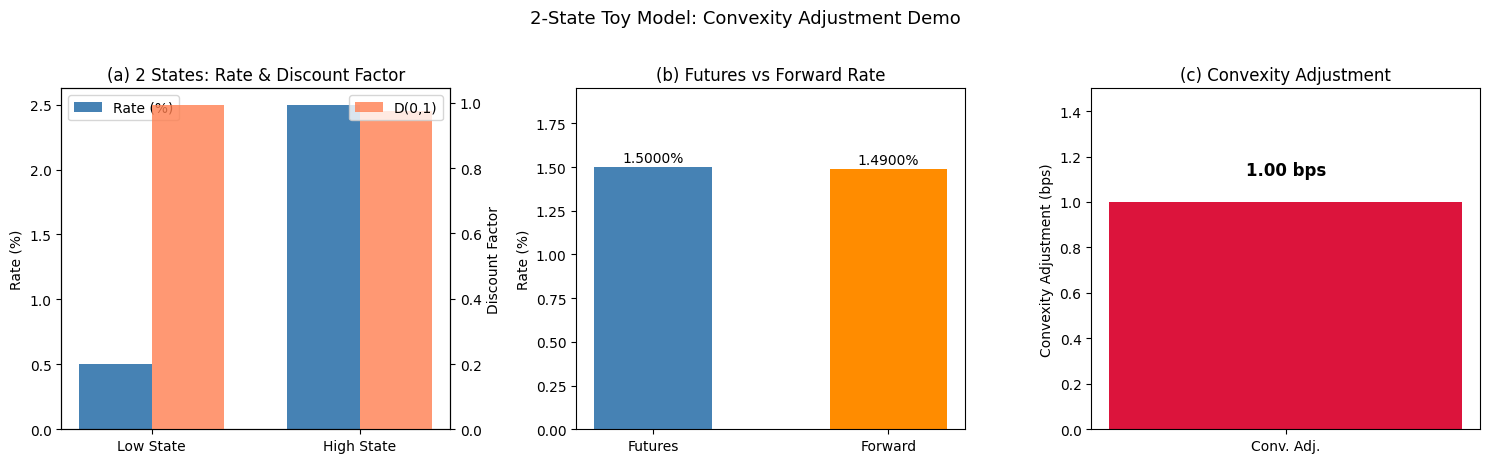

In [7]:
# --- 2-state model 可視化 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) 各状態の金利と割引係数
ax = axes[0]
x_pos = np.array([0, 1])
bar_width = 0.35
ax.bar(x_pos - bar_width/2, [rate_low * 100, rate_high * 100],
       bar_width, label="Rate (%)", color="steelblue")
ax2 = ax.twinx()
ax2.bar(x_pos + bar_width/2, [df_low, df_high],
        bar_width, label="D(0,1)", color="coral", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(["Low State", "High State"])
ax.set_ylabel("Rate (%)")
ax2.set_ylabel("Discount Factor")
ax.set_title("(a) 2 States: Rate & Discount Factor")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

# (b) Futures vs Forward
ax = axes[1]
labels = ["Futures", "Forward"]
values = [futures_rate * 100, forward_rate * 100]
colors = ["steelblue", "darkorange"]
bars = ax.bar(labels, values, color=colors, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Rate (%)")
ax.set_title("(b) Futures vs Forward Rate")
ax.set_ylim(0, max(values) * 1.3)

# (c) Convexity adjustment
ax = axes[2]
ax.bar(["Conv. Adj."], [ca * 10000], color="crimson", width=0.4)
ax.text(0, ca * 10000 + 0.1, f"{ca * 10000:.2f} bps",
        ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylabel("Convexity Adjustment (bps)")
ax.set_title("(c) Convexity Adjustment")
ax.set_ylim(0, ca * 10000 * 1.5)

fig.suptitle("2-State Toy Model: Convexity Adjustment Demo", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2 状態モデルの考察

- Futures rate は 2 状態の**単純平均**
- Forward rate は割引係数で**加重平均**したもの
- High state（高金利 → 低い割引係数）は加重平均で軽くなり、Low state が重くなる
- 結果として $f < F$ → **Convexity Adjustment > 0**

もし 2 状態とも同じ金利（deterministic）であれば、Cov$(D, L) = 0$ となり調整はゼロです。

---
## 4. メインモデル: Short-Rate Simulation (Vasicek)

### モデル選択: Vasicek / Ornstein-Uhlenbeck

教材用途として **Vasicek モデル** を採用します。

$$
dr_t = \kappa(\theta - r_t)\,dt + \sigma\,dW_t
$$

**選択理由:**

1. **解析解が豊富** — ゼロクーポン債価格・フォワードレートに閉形式解があり、Monte Carlo 結果の妥当性チェックが容易
2. **パラメータの直感性** — $\kappa$（平均回帰速度）、$\theta$（長期平均金利）、$\sigma$（ボラ）の3つで制御でき、convexity adjustment への影響を個別に確認しやすい
3. **実装のシンプルさ** — Euler-Maruyama 離散化が容易で、コードの可読性を保てる
4. **負金利の許容** — 現代の低金利環境の教材として自然（教育目的では大きな問題ではない）

> **注意:** Vasicek モデルは金利が正規分布に従うため、理論上マイナス金利が発生し得ます。
> 教材としてはこの単純さが利点ですが、実務ではこの点に注意が必要です。

In [8]:
# ============================================================
# パラメータ設定（ここで一括管理）
# ============================================================

# Vasicek model parameters
r0 = 0.005       # 初期短期金利 (0.5%)
theta = 0.01     # 長期平均金利 (1.0%)
kappa = 0.3      # 平均回帰速度

# 3 ケースのボラティリティ
sigma_cases = {
    "Deterministic (σ=0.00)": 0.00,
    "Low Vol (σ=0.01)": 0.01,
    "High Vol (σ=0.03)": 0.03,
}

# 金利先物の対象期間
T1 = 2.0         # forward start (years)
T2 = 2.25        # forward end   (years) — 3M tenor
tau = T2 - T1     # day count fraction

# Monte Carlo settings
n_paths = 20_000   # シミュレーションパス数
dt = 1 / 252       # 時間刻み（営業日ベース）
seed = 42           # 乱数シード

# 満期依存性分析用の T1 リスト
T1_list = [0.5, 1.0, 2.0, 3.0, 5.0]

print("=== Parameters ===")
print(f"r0 = {r0}, theta = {theta}, kappa = {kappa}")
print(f"T1 = {T1}, T2 = {T2}, tau = {tau}")
print(f"n_paths = {n_paths}, dt = {dt:.6f}")
print(f"sigma cases: {list(sigma_cases.values())}")

=== Parameters ===
r0 = 0.005, theta = 0.01, kappa = 0.3
T1 = 2.0, T2 = 2.25, tau = 0.25
n_paths = 20000, dt = 0.003968
sigma cases: [0.0, 0.01, 0.03]


In [9]:
def simulate_vasicek(
    r0: float,
    kappa: float,
    theta: float,
    sigma: float,
    T: float,
    dt: float,
    n_paths: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    """Vasicek モデルで短期金利パスを Euler-Maruyama 法でシミュレーション。

    Parameters
    ----------
    r0 : float
        初期短期金利
    kappa : float
        平均回帰速度
    theta : float
        長期平均金利
    sigma : float
        ボラティリティ
    T : float
        シミュレーション期間 (years)
    dt : float
        時間刻み幅 (years)
    n_paths : int
        シミュレーションパス数
    rng : np.random.Generator
        乱数生成器

    Returns
    -------
    time_grid : np.ndarray, shape (n_steps+1,)
        時間グリッド
    r_paths : np.ndarray, shape (n_paths, n_steps+1)
        短期金利パス
    """
    n_steps = int(round(T / dt))
    time_grid = np.linspace(0, T, n_steps + 1)
    r_paths = np.zeros((n_paths, n_steps + 1))
    r_paths[:, 0] = r0

    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        r_paths[:, i + 1] = (
            r_paths[:, i]
            + kappa * (theta - r_paths[:, i]) * dt
            + sigma * dW
        )

    return time_grid, r_paths


def compute_discount_factor(r_paths: np.ndarray, dt: float, end_idx: int) -> np.ndarray:
    """短期金利パスから区間 [0, end_idx*dt] の割引係数を計算。

    台形近似で ∫r(s)ds を計算し、D = exp(-∫r ds) を返す。

    Parameters
    ----------
    r_paths : np.ndarray, shape (n_paths, n_steps+1)
    dt : float
    end_idx : int
        時間グリッド上のインデックス

    Returns
    -------
    np.ndarray, shape (n_paths,)
    """
    integral = np.trapezoid(r_paths[:, :end_idx + 1], dx=dt, axis=1)
    return np.exp(-integral)


def compute_forward_rate_3m(
    r_paths: np.ndarray, dt: float, idx_T1: int, idx_T2: int, tau: float
) -> np.ndarray:
    """パスごとに、[T1, T2] 区間の 3M 単利相当金利を計算。

    L(T1, T2) = (1/tau) * (exp(∫_{T1}^{T2} r(s) ds) - 1)

    Parameters
    ----------
    r_paths : np.ndarray, shape (n_paths, n_steps+1)
    dt : float
    idx_T1 : int
    idx_T2 : int
    tau : float
        期間（年）

    Returns
    -------
    np.ndarray, shape (n_paths,)
    """
    integral = np.trapezoid(r_paths[:, idx_T1:idx_T2 + 1], dx=dt, axis=1)
    return (np.exp(integral) - 1.0) / tau


def compute_futures_forward(
    D_T1: np.ndarray, L_T1_T2: np.ndarray
) -> Dict[str, float]:
    """Futures rate, forward rate, convexity adjustment を計算。

    Parameters
    ----------
    D_T1 : np.ndarray, shape (n_paths,)
        各パスの D(0, T1)
    L_T1_T2 : np.ndarray, shape (n_paths,)
        各パスの L(T1, T2)

    Returns
    -------
    dict
    """
    futures_rate = np.mean(L_T1_T2)
    forward_rate = np.mean(D_T1 * L_T1_T2) / np.mean(D_T1)
    ca = futures_rate - forward_rate
    mean_D = np.mean(D_T1)
    cov_DL = np.cov(D_T1, L_T1_T2, ddof=0)[0, 1]

    return {
        "futures_rate": futures_rate,
        "forward_rate": forward_rate,
        "convexity_adj": ca,
        "convexity_adj_bps": ca * 10_000,
        "mean_D": mean_D,
        "cov_DL": cov_DL,
    }

print("Functions defined successfully.")

Functions defined successfully.


In [10]:
# ============================================================
# メインシミュレーション: 3 ケースを実行
# ============================================================

rng = np.random.default_rng(seed)

# 結果格納
sim_results: Dict[str, dict] = {}

for case_name, sigma in sigma_cases.items():
    print(f"\n--- {case_name} ---")

    # T2 まで simulate
    time_grid, r_paths = simulate_vasicek(
        r0, kappa, theta, sigma, T2, dt, n_paths, rng
    )

    # T1, T2 のインデックスを求める
    idx_T1 = int(round(T1 / dt))
    idx_T2 = int(round(T2 / dt))

    # D(0, T1) と L(T1, T2)
    D_T1 = compute_discount_factor(r_paths, dt, idx_T1)
    L_T1_T2 = compute_forward_rate_3m(r_paths, dt, idx_T1, idx_T2, tau)

    # Futures / Forward / CA
    result = compute_futures_forward(D_T1, L_T1_T2)
    result["time_grid"] = time_grid
    result["r_paths"] = r_paths
    result["D_T1"] = D_T1
    result["L_T1_T2"] = L_T1_T2
    result["sigma"] = sigma

    sim_results[case_name] = result

    print(f"  Futures rate   = {result['futures_rate']:.6f} ({result['futures_rate']*100:.4f}%)")
    print(f"  Forward rate   = {result['forward_rate']:.6f} ({result['forward_rate']*100:.4f}%)")
    print(f"  Conv. Adj.     = {result['convexity_adj_bps']:.2f} bps")
    print(f"  Mean D(0,T1)   = {result['mean_D']:.6f}")
    print(f"  Cov(D, L)      = {result['cov_DL']:.10f}")


--- Deterministic (σ=0.00) ---
  Futures rate   = 0.007364 (0.7364%)
  Forward rate   = 0.007364 (0.7364%)
  Conv. Adj.     = 0.00 bps
  Mean D(0,T1)   = 0.987596
  Cov(D, L)      = 0.0000000000

--- Low Vol (σ=0.01) ---
  Futures rate   = 0.007398 (0.7398%)
  Forward rate   = 0.007288 (0.7288%)
  Conv. Adj.     = 1.10 bps
  Mean D(0,T1)   = 0.987788
  Cov(D, L)      = -0.0001087121

--- High Vol (σ=0.03) ---
  Futures rate   = 0.007531 (0.7531%)
  Forward rate   = 0.006522 (0.6522%)
  Conv. Adj.     = 10.09 bps
  Mean D(0,T1)   = 0.988187
  Cov(D, L)      = -0.0009967331


In [11]:
# 結果をテーブルにまとめる
summary_rows = []
for case_name, res in sim_results.items():
    summary_rows.append({
        "Case": case_name,
        "σ": res["sigma"],
        "Futures (%)": f"{res['futures_rate']*100:.4f}",
        "Forward (%)": f"{res['forward_rate']*100:.4f}",
        "CA (bps)": f"{res['convexity_adj_bps']:.2f}",
        "E[D(0,T1)]": f"{res['mean_D']:.6f}",
        "Cov(D,L)": f"{res['cov_DL']:.2e}",
    })

df_summary = pd.DataFrame(summary_rows)
print("\n=== Summary Table ===")
print(df_summary.to_string(index=False))


=== Summary Table ===
                  Case    σ Futures (%) Forward (%) CA (bps) E[D(0,T1)]  Cov(D,L)
Deterministic (σ=0.00) 0.00      0.7364      0.7364     0.00   0.987596  0.00e+00
      Low Vol (σ=0.01) 0.01      0.7398      0.7288     1.10   0.987788 -1.09e-04
     High Vol (σ=0.03) 0.03      0.7531      0.6522    10.09   0.988187 -9.97e-04


---
## 5. 可視化

### 5.1 短期金利パスの描画

3 ケースそれぞれで代表的な短期金利パスを描画します。
Deterministic（σ=0）ではすべてのパスが一致し、ボラティリティが高いほどパスが広がることを確認します。

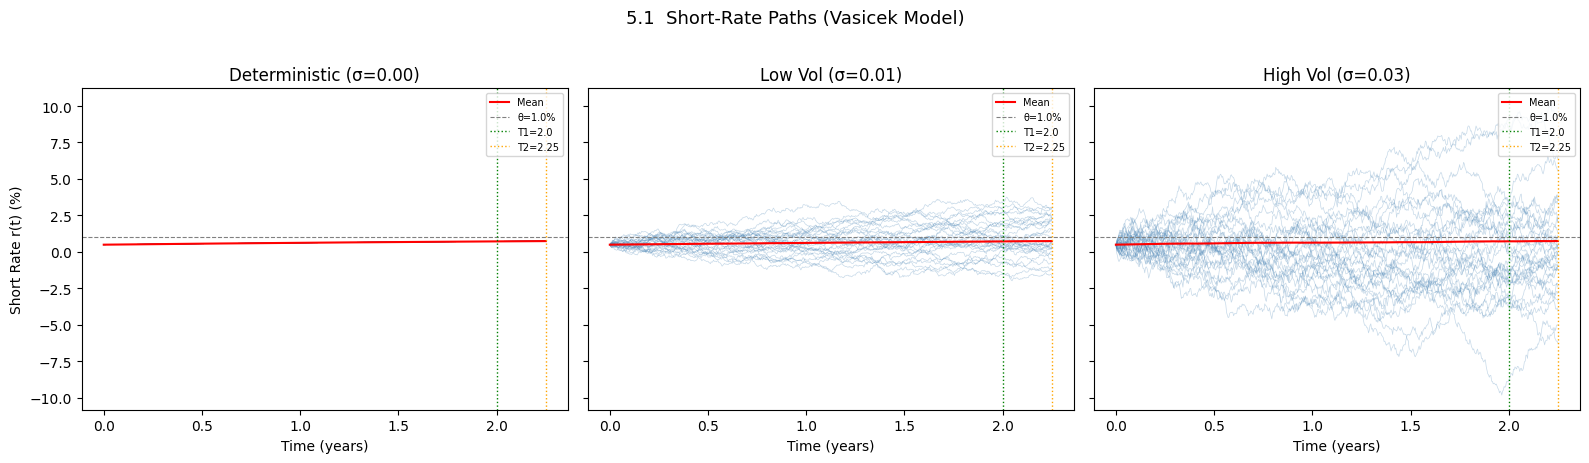

In [12]:
n_sample_paths = 30  # 表示するパス数

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (case_name, res) in zip(axes, sim_results.items()):
    tg = res["time_grid"]
    rp = res["r_paths"]

    for j in range(min(n_sample_paths, rp.shape[0])):
        ax.plot(tg, rp[j, :] * 100, alpha=0.3, linewidth=0.5, color="steelblue")

    # 平均パス
    ax.plot(tg, np.mean(rp, axis=0) * 100, color="red", linewidth=1.5, label="Mean")

    ax.axhline(y=theta * 100, color="gray", linestyle="--", linewidth=0.8, label=f"θ={theta*100:.1f}%")
    ax.axvline(x=T1, color="green", linestyle=":", linewidth=1.0, label=f"T1={T1}")
    ax.axvline(x=T2, color="orange", linestyle=":", linewidth=1.0, label=f"T2={T2}")
    ax.set_xlabel("Time (years)")
    ax.set_title(case_name)
    ax.legend(fontsize=7, loc="upper right")

axes[0].set_ylabel("Short Rate r(t) (%)")
fig.suptitle("5.1  Short-Rate Paths (Vasicek Model)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 将来金利 $L(T_1,T_2)$ の分布

ボラティリティが高いほど、将来の 3M 金利の分布が広がることを確認します。

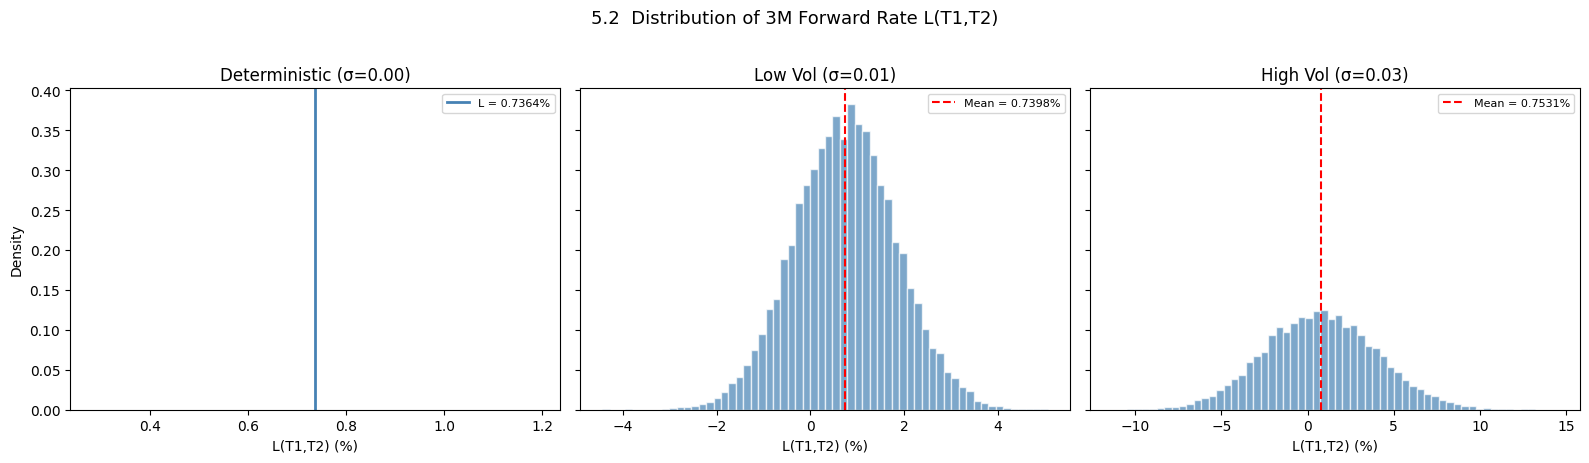

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (case_name, res) in zip(axes, sim_results.items()):
    L = res["L_T1_T2"] * 100  # パーセント表示

    if res["sigma"] == 0:
        # deterministic: ほぼ 1 点に集中
        ax.axvline(x=np.mean(L), color="steelblue", linewidth=2,
                   label=f"L = {np.mean(L):.4f}%")
        ax.set_xlim(np.mean(L) - 0.5, np.mean(L) + 0.5)
    else:
        ax.hist(L, bins=60, density=True, alpha=0.7, color="steelblue", edgecolor="white")
        ax.axvline(x=np.mean(L), color="red", linestyle="--", linewidth=1.5,
                   label=f"Mean = {np.mean(L):.4f}%")

    ax.set_xlabel("L(T1,T2) (%)")
    ax.set_title(case_name)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Density")
fig.suptitle("5.2  Distribution of 3M Forward Rate L(T1,T2)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 割引係数 $D(0,T_1)$ と将来金利 $L(T_1,T_2)$ の散布図

金利が高い状態では割引係数が低くなるため、**負の相関**（負の共分散）が観察されるはずです。
この共分散が convexity adjustment の源泉です。

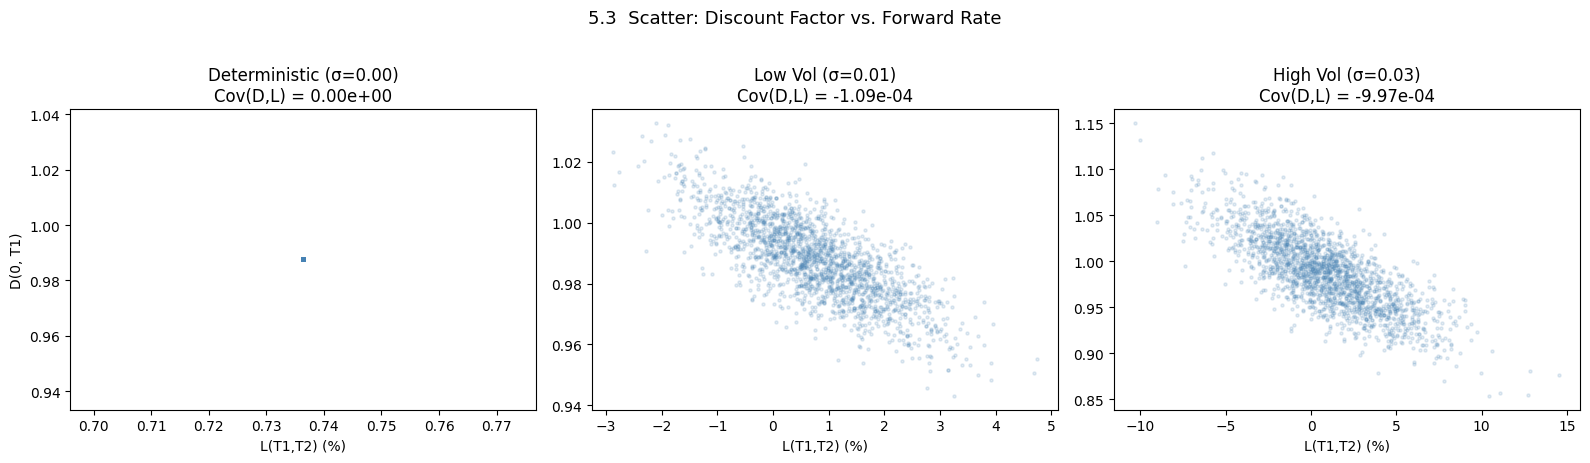

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

n_scatter = 2000  # 描画点数（見やすさのため間引き）

for ax, (case_name, res) in zip(axes, sim_results.items()):
    D = res["D_T1"][:n_scatter]
    L = res["L_T1_T2"][:n_scatter] * 100

    ax.scatter(L, D, alpha=0.15, s=5, color="steelblue")
    ax.set_xlabel("L(T1,T2) (%)")
    ax.set_title(f"{case_name}\nCov(D,L) = {res['cov_DL']:.2e}")

axes[0].set_ylabel("D(0, T1)")
fig.suptitle("5.3  Scatter: Discount Factor vs. Forward Rate", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.4 Futures Rate / Forward Rate / Convexity Adjustment の比較

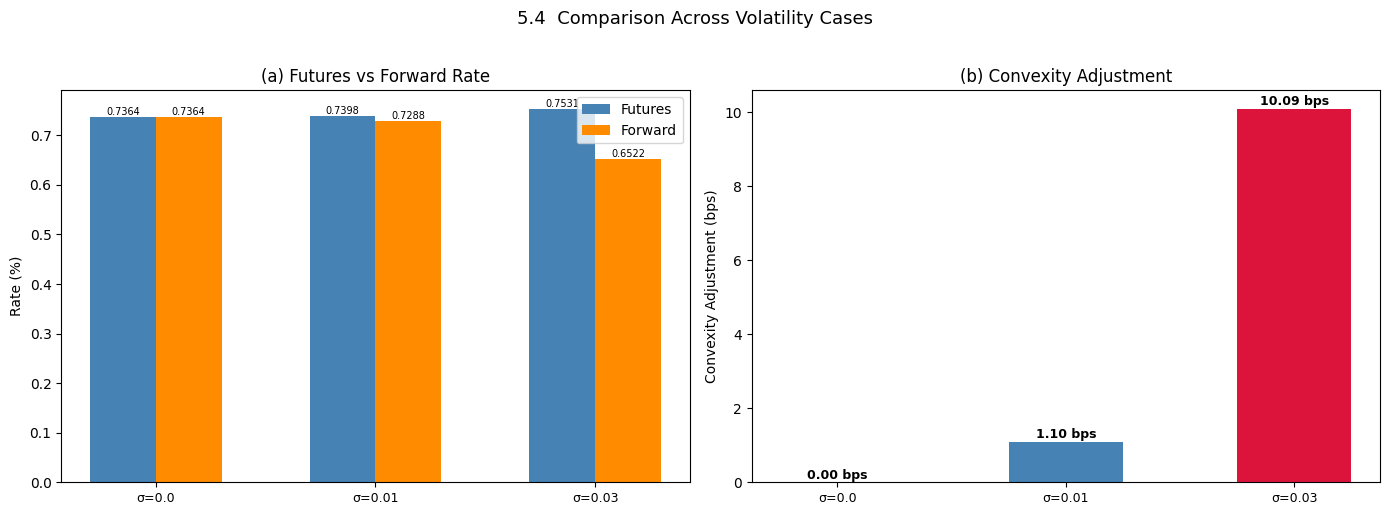


                  Case    σ Futures (%) Forward (%) CA (bps) E[D(0,T1)]  Cov(D,L)
Deterministic (σ=0.00) 0.00      0.7364      0.7364     0.00   0.987596  0.00e+00
      Low Vol (σ=0.01) 0.01      0.7398      0.7288     1.10   0.987788 -1.09e-04
     High Vol (σ=0.03) 0.03      0.7531      0.6522    10.09   0.988187 -9.97e-04


In [15]:
case_names = list(sim_results.keys())
futures_vals = [sim_results[c]["futures_rate"] * 100 for c in case_names]
forward_vals = [sim_results[c]["forward_rate"] * 100 for c in case_names]
ca_vals = [sim_results[c]["convexity_adj_bps"] for c in case_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Futures vs Forward
ax = axes[0]
x = np.arange(len(case_names))
bar_w = 0.3
bars1 = ax.bar(x - bar_w/2, futures_vals, bar_w, label="Futures", color="steelblue")
bars2 = ax.bar(x + bar_w/2, forward_vals, bar_w, label="Forward", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([f"σ={sim_results[c]['sigma']}" for c in case_names], fontsize=9)
ax.set_ylabel("Rate (%)")
ax.set_title("(a) Futures vs Forward Rate")
ax.legend()
# 数値ラベル
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7)

# (b) Convexity adjustment
ax = axes[1]
colors = ["gray", "steelblue", "crimson"]
bars = ax.bar(x, ca_vals, 0.5, color=colors)
for bar, val in zip(bars, ca_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f} bps", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"σ={sim_results[c]['sigma']}" for c in case_names], fontsize=9)
ax.set_ylabel("Convexity Adjustment (bps)")
ax.set_title("(b) Convexity Adjustment")

fig.suptitle("5.4  Comparison Across Volatility Cases", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# テーブル再掲
print("\n" + df_summary.to_string(index=False))

### 5.5 満期依存性: $T_1$ を変えたときの Convexity Adjustment

$T_1$ を 0.5, 1.0, 2.0, 3.0, 5.0 年と変化させ、$T_2 = T_1 + 0.25$（3M）として convexity adjustment を計算します。
- 満期が遠いほど adjustment が大きくなる
- ボラが高いほど adjustment が大きくなる

ことを確認します。

In [16]:
def compute_ca_for_maturity(
    r0: float,
    kappa: float,
    theta: float,
    sigma: float,
    T1: float,
    tau: float,
    dt: float,
    n_paths: int,
    rng: np.random.Generator,
) -> Dict[str, float]:
    """指定した T1 に対する convexity adjustment を計算。

    Parameters
    ----------
    r0, kappa, theta, sigma : float
        Vasicek パラメータ
    T1 : float
        Forward start
    tau : float
        Tenor (T2 - T1)
    dt : float
        時間刻み幅
    n_paths : int
        パス数
    rng : np.random.Generator
        乱数生成器

    Returns
    -------
    dict
    """
    T2 = T1 + tau
    time_grid, r_paths = simulate_vasicek(r0, kappa, theta, sigma, T2, dt, n_paths, rng)
    idx_T1 = int(round(T1 / dt))
    idx_T2 = int(round(T2 / dt))
    D_T1 = compute_discount_factor(r_paths, dt, idx_T1)
    L_T1_T2 = compute_forward_rate_3m(r_paths, dt, idx_T1, idx_T2, tau)
    return compute_futures_forward(D_T1, L_T1_T2)

print("Computing maturity dependence... (this may take a moment)")

maturity_results: Dict[str, List[float]] = {case: [] for case in sigma_cases}

for case_name, sigma in sigma_cases.items():
    for t1 in T1_list:
        rng_mat = np.random.default_rng(seed + int(t1 * 100))  # 再現性を保ちつつ独立
        res = compute_ca_for_maturity(r0, kappa, theta, sigma, t1, tau, dt, n_paths, rng_mat)
        maturity_results[case_name].append(res["convexity_adj_bps"])
    print(f"  {case_name}: done")

print("Done.")

Computing maturity dependence... (this may take a moment)
  Deterministic (σ=0.00): done
  Low Vol (σ=0.01): done
  High Vol (σ=0.03): done
Done.


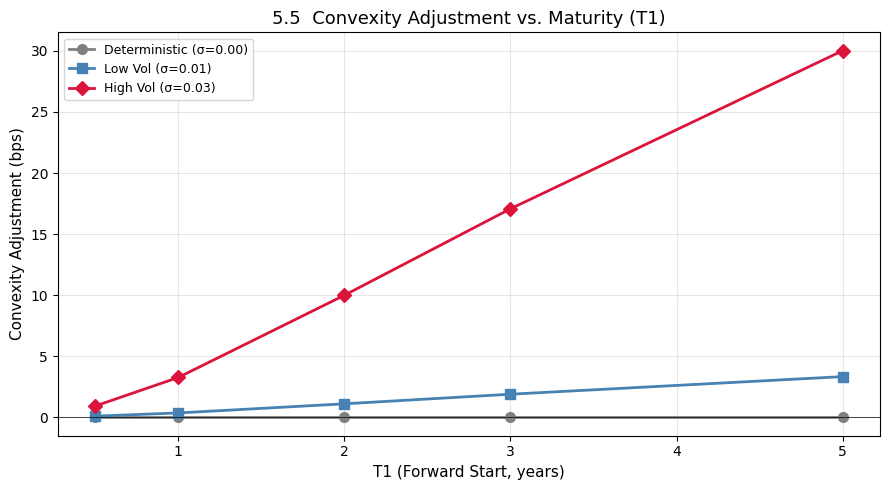


 T1 σ=0.00 (bps) σ=0.01 (bps) σ=0.03 (bps)
0.5         0.00         0.10         0.93
1.0        -0.00         0.36         3.27
2.0         0.00         1.11        10.00
3.0         0.00         1.90        17.08
5.0         0.00         3.34        30.02


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

markers = ["o", "s", "D"]
colors = ["gray", "steelblue", "crimson"]

for i, (case_name, ca_list) in enumerate(maturity_results.items()):
    ax.plot(T1_list, ca_list, marker=markers[i], color=colors[i],
            linewidth=2, markersize=7, label=case_name)

ax.set_xlabel("T1 (Forward Start, years)", fontsize=11)
ax.set_ylabel("Convexity Adjustment (bps)", fontsize=11)
ax.set_title("5.5  Convexity Adjustment vs. Maturity (T1)", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

# テーブル表示
mat_df = pd.DataFrame({"T1": T1_list})
for case_name, ca_list in maturity_results.items():
    short_name = case_name.split("(")[1].rstrip(")") if "(" in case_name else case_name
    mat_df[short_name + " (bps)"] = [f"{v:.2f}" for v in ca_list]
print("\n" + mat_df.to_string(index=False))

---
## 6. TONA / OIS への接続 — 実務的な視点

### 3M TONA 先物

日本市場では、**3ヶ月物 TONA 先物**（東京金融取引所上場）が重要な金利先物です。

- 対象金利: 3 ヶ月間の TONA（無担保コール翌日物金利）複利年率
- 価格表示: **IMM 方式** → $\text{Price} = 100 - \text{Rate}$
- 最終決済: 参照期間終了後に確定した複利 TONA で現金決済
- 受渡日: IMM 日付（3月・6月・9月・12月の第3水曜日）

### Convexity Adjustment の実務的重要性

OIS カーブ（TONA スワップカーブ）を構築する際、**TONA 先物のレートをそのまま forward rate として使うことはできません**。

$$
f_{\text{OIS}} = F_{\text{TONA futures}} - \text{Convexity Adjustment}
$$

この調整を行わないと、以下のような問題が生じます:

1. **カーブの整合性** — 先物から構築したカーブと OIS スワップから構築したカーブが一致しない
2. **アービトラージ** — 先物と FRA/OIS 間の理論的な無裁定関係が崩れる
3. **リスク管理** — ヘッジ比率が不正確になる

### 本 notebook との関係

本 notebook では、**generic な Vasicek 短期金利モデル**を用いて convexity adjustment のメカニズムを示しました。

実務での違い:

| 本 notebook | 実務 |
|---|---|
| Vasicek（1 factor, 正規分布） | Hull-White, SABR, マルチファクターモデル等 |
| 連続複利の短期金利 | TONA 日次複利の離散計算 |
| 固定パラメータ | 市場データにキャリブレーション |
| 単一商品の分析 | カーブ全体のブートストラップ |

実務的な convexity adjustment の計算方法は、モデル前提・市場慣行・カーブ構築方法に依存し、
本 notebook の簡略化されたアプローチとは異なる場合があります。

---
## 7. 検証と Sanity Check

Monte Carlo 結果に対して以下の基本的な性質を確認します。

In [18]:
# ============================================================
# Sanity Checks
# ============================================================

print("=== Sanity Checks ===")
print()

# --- Check 1: Deterministic case → CA ≈ 0 ---
det_key = "Deterministic (σ=0.00)"
det_ca = sim_results[det_key]["convexity_adj_bps"]
print(f"[Check 1] Deterministic CA = {det_ca:.4f} bps")
assert abs(det_ca) < 0.5, f"FAIL: Deterministic CA should be ≈ 0, got {det_ca:.4f} bps"
print("  → PASS: CA ≈ 0 in deterministic case")
print()

# --- Check 2: CA increases with sigma ---
ca_values = [sim_results[k]["convexity_adj_bps"] for k in sigma_cases]
print(f"[Check 2] CA values: {[f'{v:.2f}' for v in ca_values]}")
# 厳密には low vol と high vol の差を見る（deterministic は ≈ 0 なのでスキップ可）
ca_low = sim_results["Low Vol (σ=0.01)"]["convexity_adj_bps"]
ca_high = sim_results["High Vol (σ=0.03)"]["convexity_adj_bps"]
assert ca_high > ca_low, f"FAIL: High vol CA ({ca_high:.2f}) should > Low vol CA ({ca_low:.2f})"
print(f"  → PASS: CA(σ=0.03)={ca_high:.2f} > CA(σ=0.01)={ca_low:.2f}")
print()

# --- Check 3: Cov(D, L) is negative for stochastic cases ---
for case_name, res in sim_results.items():
    if res["sigma"] > 0:
        cov_val = res["cov_DL"]
        print(f"[Check 3] {case_name}: Cov(D,L) = {cov_val:.2e}")
        assert cov_val < 0, f"FAIL: Cov(D,L) should be < 0, got {cov_val}"
        print(f"  → PASS: Cov(D,L) < 0")
print()

# --- Check 4: Futures >= Forward for stochastic cases ---
for case_name, res in sim_results.items():
    if res["sigma"] > 0:
        f_rate = res["futures_rate"]
        fw_rate = res["forward_rate"]
        print(f"[Check 4] {case_name}: Futures={f_rate:.6f}, Forward={fw_rate:.6f}")
        assert f_rate >= fw_rate - 1e-6, \
            f"FAIL: Futures rate should >= Forward rate"
        print(f"  → PASS: Futures >= Forward")
print()

# --- Check 5: -Cov(D,L)/E[D] ≈ CA ---
print("[Check 5] Verify CA ≈ -Cov(D,L)/E[D]")
for case_name, res in sim_results.items():
    if res["sigma"] > 0:
        ca_formula = -res["cov_DL"] / res["mean_D"]
        ca_direct = res["convexity_adj"]
        diff_bps = abs(ca_formula - ca_direct) * 10_000
        print(f"  {case_name}: CA(direct)={ca_direct*10000:.2f} bps, "
              f"-Cov/E[D]={ca_formula*10000:.2f} bps, diff={diff_bps:.2f} bps")
        assert diff_bps < 1.0, f"FAIL: Too large discrepancy ({diff_bps:.2f} bps)"
        print(f"  → PASS")

print("\n✓ All sanity checks passed.")

=== Sanity Checks ===

[Check 1] Deterministic CA = 0.0000 bps
  → PASS: CA ≈ 0 in deterministic case

[Check 2] CA values: ['0.00', '1.10', '10.09']
  → PASS: CA(σ=0.03)=10.09 > CA(σ=0.01)=1.10

[Check 3] Low Vol (σ=0.01): Cov(D,L) = -1.09e-04
  → PASS: Cov(D,L) < 0
[Check 3] High Vol (σ=0.03): Cov(D,L) = -9.97e-04
  → PASS: Cov(D,L) < 0

[Check 4] Low Vol (σ=0.01): Futures=0.007398, Forward=0.007288
  → PASS: Futures >= Forward
[Check 4] High Vol (σ=0.03): Futures=0.007531, Forward=0.006522
  → PASS: Futures >= Forward

[Check 5] Verify CA ≈ -Cov(D,L)/E[D]
  Low Vol (σ=0.01): CA(direct)=1.10 bps, -Cov/E[D]=1.10 bps, diff=0.00 bps
  → PASS
  High Vol (σ=0.03): CA(direct)=10.09 bps, -Cov/E[D]=10.09 bps, diff=0.00 bps
  → PASS

✓ All sanity checks passed.


---
## 8. まとめ

### なぜ Futures Rate と Forward Rate がズレるのか

- **Futures** は日次値洗いにより、PnL のタイミングが毎日発生する。再投資（再調達）金利が市場金利に連動するため、**金利の経路に依存した非対称な期待値**になる。
- **Forward** は満期時にまとめて精算するため、割引係数で加重した条件付き期待値となる。
- この違いは、$\text{Cov}(D(0,T_1),\, L(T_1,T_2))$ という共分散項に集約される。

### なぜ Deterministic ではズレないのか

- ボラティリティが 0 の世界では、割引係数 $D$ も金利 $L$ も確定値になるため、$\text{Cov}(D, L) = 0$。
- 加重平均も単純平均と一致し、futures rate = forward rate となる。

### なぜ Stochastic かつ High Vol でズレが大きいのか

- ボラティリティが高いほど、金利 $L$ と割引係数 $D$ の共変動が大きくなり、$|\text{Cov}(D, L)|$ が増大する。
- 金利が高い状態では割引係数が低くなる（$D$ と $L$ は負相関）ため、forward の加重平均では高金利状態が**割り引かれ**、forward rate が futures rate より低くなる。
- さらに、満期 $T_1$ が遠いほど $D(0, T_1)$ のばらつきが大きくなるため、共分散が拡大し adjustment も増える。

### STIR Futures / TONA Futures / OIS カーブ実務で重要なこと

- 先物レートをそのまま OIS forward rate として使うと、**カーブにバイアス**が入る。
- Convexity adjustment は概ね **数 bps ～ 十数 bps** のオーダーだが、遠い限月・高ボラ環境では無視できない。
- 実務のカーブ構築では、先物から OIS カーブをブートストラップする際に、**モデルベースの convexity adjustment** を先物レートから引いてから使う。
- 調整の大きさはモデル選択（Hull-White, SABR 等）やキャリブレーションに依存するため、**モデルリスク**の存在も認識が必要。

---
## 今後の発展

本 notebook を基に、以下のトピックに拡張できます。

### 1. Hull-White 1 Factor モデル
- Vasicek モデルに **時間依存のドリフト** $\theta(t)$ を導入
- 市場の初期イールドカーブにフィットさせることが可能
- 実務的なキャリブレーションの出発点

### 2. TONA 先物の IMM 日付対応
- 3月・6月・9月・12月の第3水曜日を参照日として設定
- TONA の実際の日次複利計算を再現
- 営業日カレンダーの組み込み

### 3. 実カーブブートストラップ
- TONA 先物価格から OIS カーブを構築
- Convexity adjustment を反復的に求めるブートストラップアルゴリズム
- OIS スワップレートとの整合性チェック

### 4. 解析的 Convexity Adjustment 公式
- Vasicek / Hull-White では closed-form の convexity adjustment formula が知られている
- Monte Carlo 結果との比較検証

### 5. マルチファクターモデル
- 2 factor Gaussian モデル（G2++）
- レベル・スロープの 2 つのファクターで、より現実的な金利変動を再現

---

*この notebook は教育目的で作成されたものであり、投資助言や実務的なプライシングを目的としたものではありません。*